# Exploración inicial del dataset

In [4]:
"""
Configuraciones iniciales
"""

import sqlite3
import pandas as pd
import json
import numpy as np
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt

# Configuración
%matplotlib inline

# Rutas
ROOT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = ROOT_DIR / 'data'
DB_PATH = DATA_DIR / 'clinica.db'
PROFILE_PATH = DATA_DIR / 'data_profile.json'

# Conectar a la base de datos
conn = sqlite3.connect(DB_PATH)

# Cargar información
patients = pd.read_sql("SELECT * FROM patients", conn)
appointments = pd.read_sql("SELECT * FROM appointments", conn)

with open(PROFILE_PATH, 'r') as f:
    profile = json.load(f)

tarifas = pd.read_csv(DATA_DIR / 'tarifas_especialidad.csv')

with open(DATA_DIR / 'catalogo_clinicas.json', 'r', encoding='utf-8') as f:
    catalogo = json.load(f)

conn.close()

## 1. ¿Cuántas filas y columnas hay por fuente? ¿Cuántos `patient_id` únicos?

In [5]:
"""
Pregunta 1
"""

# Resumen de fuentes
fuentes = {
    'patients': {'filas': len(patients), 'columnas': len(patients.columns)},
    'appointments': {'filas': len(appointments), 'columnas': len(appointments.columns)},
    'tarifas': {'filas': len(tarifas), 'columnas': len(tarifas.columns)}
}

df_fuentes = pd.DataFrame(fuentes).T
df_fuentes.columns = ['Filas', 'Columnas']
display(df_fuentes)

# Patient IDs únicos
unique_patients = patients['patient_id'].nunique()
unique_patients_appt = appointments['patient_id'].nunique()

print(f"\n• Cantidad de Patient IDs únicos en patients: {unique_patients:,}")

,Filas,Columnas
patients,8000,6
appointments,60581,10
tarifas,40,5



• Cantidad de Patient IDs únicos en patients: 8,000


## 2. ¿Qué porcentaje de nulos tiene cada columna?

In [6]:
"""
Pregunta 2
"""

# Porcentaje de nulos en patients
nulos_patients = (patients.isnull().sum() / len(patients) * 100).round(2)
nulos_patients = nulos_patients[nulos_patients > 0]

# Porcentaje de nulos en appointments
nulos_appointments = (appointments.isnull().sum() / len(appointments) * 100).round(2)
nulos_appointments = nulos_appointments[nulos_appointments > 0]

print("• Nulos en patients:")
if len(nulos_patients) > 0:
    display(nulos_patients)
else:
    print("  Sin nulos")

print("\n• Nulos en appointments:")
if len(nulos_appointments) > 0:
    display(nulos_appointments)
else:
    print("  Sin nulos")

nulos_specialty = appointments['specialty'].isnull().sum()
nulos_amount = appointments['amount_charged'].isnull().sum()
print(f"\n• Nulos por D3:")
print(f"  specialty NULL: {nulos_specialty:,} ({nulos_specialty/len(appointments)*100:.2f}%)")
print(f"  amount_charged NULL: {nulos_amount:,} ({nulos_amount/len(appointments)*100:.2f}%)")

• Nulos en patients:
  Sin nulos

• Nulos en appointments:


specialty         1.45
amount_charged    1.48
dtype: float64


• Nulos por D3:
  specialty NULL: 881 (1.45%)
  amount_charged NULL: 898 (1.48%)


## 3. ¿Cuántas filas se pierden con un `INNER JOIN` ingenuo

In [7]:
"""
Pregunta 3
"""

# INNER JOIN ingenuo
joined = appointments.merge(patients, on='patient_id', how='inner')
joined = joined.merge(tarifas, left_on=['clinic_code', 'specialty'], 
                      right_on=['clinic_code', 'specialty'], how='inner')

print(f"• Resultados del INNER JOIN:")
print(f"  Citas originales: {len(appointments):,}")
print(f"  Después de JOIN con patients: {len(appointments.merge(patients, on='patient_id', how='inner')):,}")
print(f"  Después de JOIN con tarifas: {len(joined):,}")
print(f"\n  Filas perdidas: {len(appointments) - len(joined):,} ({((len(appointments) - len(joined)) / len(appointments) * 100):.2f}%)")

lost_patients = len(appointments) - len(appointments.merge(patients, on='patient_id', how='inner'))
lost_tarifas = len(appointments.merge(patients, on='patient_id', how='inner')) - len(joined)

print(f"  Perdidas por patient_id (FK huérfana D1): {lost_patients:,}")
print(f"  Perdidas por tarifa (especialidad/clínica no encontrada): {lost_tarifas:,}")

• Resultados del INNER JOIN:
  Citas originales: 60,581
  Después de JOIN con patients: 59,393
  Después de JOIN con tarifas: 54,890

  Filas perdidas: 5,691 (9.39%)
  Perdidas por patient_id (FK huérfana D1): 1,188
  Perdidas por tarifa (especialidad/clínica no encontrada): 4,503


## 4. ¿Qué columnas traen inconsistencias de formato o nomenclatura? Lista los valores distintos de `specialty` y de `clinic_code`.

In [8]:
"""
Pregunta 4
"""

# Análisis de specialty
specialty_values = appointments['specialty'].dropna().unique()
print(f"• Valores únicos en specialty: {len(specialty_values)}")
print("\n• Valores de specialty:")
for val in sorted(specialty_values):
    count = appointments[appointments['specialty'] == val].shape[0]
    print(f"  {repr(val)}: {count:,} citas")

specialties_valid = [
    "Medicina General", "Pediatría", "Traumatología", "Cardiología",
    "Dermatología", "Ginecología", "Odontología", "Oftalmología"
]

aliases = [v for v in specialty_values if v not in specialties_valid and pd.notna(v)]
print(f"\n• Aliases encontrados (D5): {len(aliases)}")
for alias in aliases:
    count = appointments[appointments['specialty'] == alias].shape[0]
    print(f"  {repr(alias)}: {count:,} citas")

# Análisis de clinic_code
clinic_values = appointments['clinic_code'].dropna().unique()
print(f"\n• Valores únicos en clinic_code: {len(clinic_values)}")
for val in sorted(clinic_values):
    count = appointments[appointments['clinic_code'] == val].shape[0]
    print(f"  {repr(val)}: {count:,} citas")

clinic_codes_valid = ['CL01', 'CL02', 'CL03', 'CL04', 'CL05']
clinic_invalid = [v for v in clinic_values if v not in clinic_codes_valid and pd.notna(v)]
print(f"\n• Clinic codes con formato alterado (D6): {len(clinic_invalid)}")
for val in clinic_invalid:
    count = appointments[appointments['clinic_code'] == val].shape[0]
    print(f"  {repr(val)}: {count:,} citas")

• Valores únicos en specialty: 42

• Valores de specialty:
  'CAR': 30 citas
  'CARDIOLOGIA': 38 citas
  'Cardiología': 3,461 citas
  'DER': 98 citas
  'DERMATOLOGIA': 98 citas
  'Dermatología': 10,207 citas
  'GIN': 65 citas
  'GINECOLOGIA': 86 citas
  'Ginecología': 6,896 citas
  'MEDICINA_GENERAL': 101 citas
  'MG': 106 citas
  'Medicina General': 9,237 citas
  'ODO': 88 citas
  'ODONTOLOGIA': 72 citas
  'OFT': 47 citas
  'OFTALMOLOGIA': 38 citas
  'Odontología': 7,111 citas
  'Oftalmología': 3,602 citas
  'PED': 56 citas
  'PEDIATRIA': 48 citas
  'Pediatría': 4,051 citas
  'TRA': 149 citas
  'TRAUMA': 119 citas
  'Traumatología': 12,568 citas
  'cardio': 29 citas
  'cardiologia': 35 citas
  'derma': 106 citas
  'dermatologia': 103 citas
  'gineco': 73 citas
  'ginecologia': 68 citas
  'med gral': 101 citas
  'med-general': 89 citas
  'medicina general ': 90 citas
  'odonto': 76 citas
  'odontologia': 76 citas
  'oftalmo': 43 citas
  'oftalmologia': 39 citas
  'ped': 37 citas
  'ped

## 5. ¿Cuántos duplicados hay y por qué clave? Separa exactos de casi-duplicados.

In [9]:
"""
Pregunta 5
"""

# Duplicados exactos (mismo appointment_id)
duplicados_exactos = appointments[appointments.duplicated(subset=['appointment_id'], keep=False)]
duplicados_exactos_count = len(duplicados_exactos) // 2

print(f"• Duplicados exactos (mismo appointment_id): {duplicados_exactos_count:,}")
print(f"   Filas involucradas: {len(duplicados_exactos):,}")

# Casi-duplicados con mismas características pero diferente ID
columnas_cita = ['patient_id', 'clinic_code', 'specialty', 'scheduled_at']
grupos = appointments.groupby(columnas_cita)

# Filtrar grupos que tienen más de un registro
casi_duplicados_list = []
for name, group in grupos:
    if len(group) > 1:
        if group['appointment_id'].nunique() > 1:
            if group['amount_charged'].nunique() > 1:
                casi_duplicados_list.append(group)

if casi_duplicados_list:
    casi_duplicados_df = pd.concat(casi_duplicados_list)
    # Cada grupo de tamaño n tiene n-1 duplicados (el primero es el original)
    casi_duplicados_count = sum(len(g) - 1 for g in casi_duplicados_list)
else:
    casi_duplicados_df = pd.DataFrame()
    casi_duplicados_count = 0

total_duplicados = duplicados_exactos_count + casi_duplicados_count

print(f"\n• Casi-duplicados (mismos datos, amount diferente): {casi_duplicados_count:,}")
print(f"   Filas involucradas: {len(casi_duplicados_df):,}")

• Duplicados exactos (mismo appointment_id): 0
   Filas involucradas: 0

• Casi-duplicados (mismos datos, amount diferente): 426
   Filas involucradas: 849


## 6. ¿Qué combinaciones son físicamente imposibles (`duration_min = 0` con cobro, cita anterior al registro del paciente)?

In [10]:
"""
Pregunta 6
"""

# Función para parsear fechas
def parse_fecha(fecha):
    if pd.isna(fecha):
        return pd.NaT
    try:
        return pd.to_datetime(fecha, format='%Y-%m-%d %H:%M:%S')
    except:
        try:
            return pd.to_datetime(fecha, format='%Y-%m-%dT%H:%M:%SZ')
        except:
            try:
                return pd.to_datetime(fecha, format='%m/%d/%Y %H:%M')
            except:
                return pd.to_datetime(fecha)

# Convertir fechas
appointments['scheduled_dt'] = appointments['scheduled_at'].apply(parse_fecha)
patients['registered_dt'] = pd.to_datetime(patients['registered_at'])

# duration_min = 0 con cobro
imposible_1 = appointments[(appointments['duration_min'] == 0) & 
                           (appointments['amount_charged'] > 0)]

# Cita antes del registro
appt_con_paciente = appointments.merge(patients[['patient_id', 'registered_dt']], 
                                        on='patient_id', how='left')
imposible_2 = appt_con_paciente[(appt_con_paciente['scheduled_dt'] < appt_con_paciente['registered_dt']) & 
                                (appt_con_paciente['scheduled_dt'].notna()) & 
                                (appt_con_paciente['registered_dt'].notna())]

total_imposibles = len(imposible_1) + len(imposible_2)

# Resultados
print("Comninaciones imposibles:")
print(f"  • duration_min=0 con cobro > 0: {len(imposible_1):,}")
print(f"  • Cita anterior al registro: {len(imposible_2):,}")
print(f"  • Total: {len(imposible_1) + len(imposible_2):,}")
print(f"  • Inyectados D7: {profile['defect_counts']['D7']:,}")
print(f"  • Diferencia: {len(imposible_1) + len(imposible_2) - profile['defect_counts']['D7']:,}")

Comninaciones imposibles:
  • duration_min=0 con cobro > 0: 147
  • Cita anterior al registro: 5,136
  • Total: 5,283
  • Inyectados D7: 306
  • Diferencia: 4,977


## 7. Muestra la concentración de citas por paciente (top 30%) y explica por qué importa para la Fase 5.

Conocer la importancia de la concentración de citas por paciente es útil porque permite entender la distribución de los datos, y por ende, influye en la decisión de cómo será tratada la información, al igual que permite definir cómo será interpretada para un uso en un problema de la vida real.

Concretamente, como se puede ver en las gráficas de abajo, el top 30% de los pacientes representa un total del 73.3% de los datos. Esto se traduce como una métrica significativa que afectará el rendimiento de las consultas, debido a que ciertos pacientes tendrán muchas más citas que otros, de la mano de esto se puede ver afectada la calidad de predicciones debido a que el modelo podría sobreajustarse a aquellos pacientes más frecuentes, o sea, la distribución de features para modelos de ML puede ser compleja y/o podría requerirse de técnicas como oversampling/undersampling o weighted loss".

Distribución de citas por paciente:
  • Total pacientes con citas: 8,338
  • Promedio de citas por paciente: 7.27
  • Mediana de citas por paciente: 4.00
  • Máximo de citas por paciente: 196
  • Mínimo de citas por paciente: 1

Top 30% de pacientes:
  • Número de pacientes: 2,501
  • Citas en top 30%: 44,397
  • Porcentaje del total: 73.3%


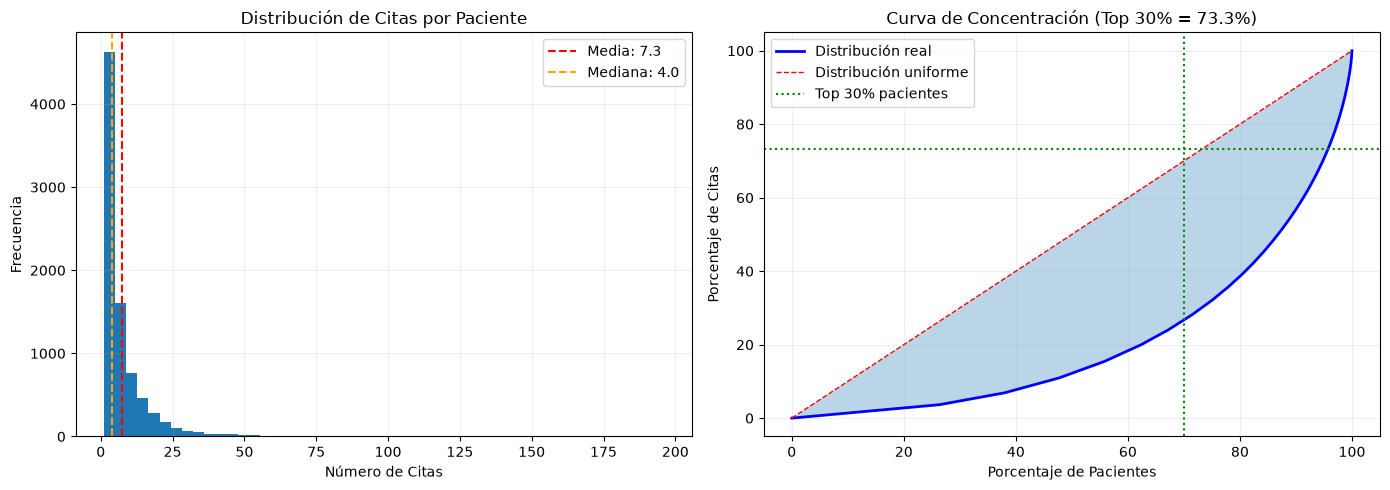

In [11]:
"""
Pregunta 7
"""

citas_por_paciente = appointments['patient_id'].value_counts()

# Estadísticas
print(f"Distribución de citas por paciente:")
print(f"  • Total pacientes con citas: {len(citas_por_paciente):,}")
print(f"  • Promedio de citas por paciente: {citas_por_paciente.mean():.2f}")
print(f"  • Mediana de citas por paciente: {citas_por_paciente.median():.2f}")
print(f"  • Máximo de citas por paciente: {citas_por_paciente.max():,}")
print(f"  • Mínimo de citas por paciente: {citas_por_paciente.min():,}")

# Top 30% de pacientes
n_pacientes = len(citas_por_paciente)
top_30 = int(n_pacientes * 0.3)
citas_top_30 = citas_por_paciente.head(top_30).sum()
total_citas = citas_por_paciente.sum()
porcentaje_top_30 = (citas_top_30 / total_citas) * 100

print(f"\nTop 30% de pacientes:")
print(f"  • Número de pacientes: {top_30:,}")
print(f"  • Citas en top 30%: {citas_top_30:,}")
print(f"  • Porcentaje del total: {porcentaje_top_30:.1f}%")

# Gráfico de concentración
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
citas_por_paciente.hist(bins=50, ax=ax1)
ax1.set_title('Distribución de Citas por Paciente')
ax1.set_xlabel('Número de Citas')
ax1.set_ylabel('Frecuencia')
ax1.axvline(citas_por_paciente.mean(), color='red', linestyle='--', label=f'Media: {citas_por_paciente.mean():.1f}')
ax1.axvline(citas_por_paciente.median(), color='orange', linestyle='--', label=f'Mediana: {citas_por_paciente.median():.1f}')
ax1.legend()
ax1.grid(True, alpha=0.2)

ax2 = axes[1]
sorted_citas = citas_por_paciente.sort_values(ascending=True)
cumsum = sorted_citas.cumsum()
cumsum_percent = cumsum / cumsum.iloc[-1] * 100
pacientes_percent = np.arange(1, len(cumsum) + 1) / len(cumsum) * 100

ax2.plot(pacientes_percent, cumsum_percent, 'b-', linewidth=2, label='Distribución real')
ax2.plot([0, 100], [0, 100], 'r--', linewidth=1, label='Distribución uniforme')
ax2.fill_between(pacientes_percent, cumsum_percent, pacientes_percent, alpha=0.3)

ax2.axvline(70, color='green', linestyle=':', label='Top 30% pacientes')
ax2.axhline(porcentaje_top_30, color='green', linestyle=':')

ax2.set_title(f'Curva de Concentración (Top 30% = {porcentaje_top_30:.1f}%)')
ax2.set_xlabel('Porcentaje de Pacientes')
ax2.set_ylabel('Porcentaje de Citas')
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## Tabla resumen de defectos D1-D7

,Defecto,Descripción,Probabilidad,Detectados,Inyectados (profile),Diferencia
0,D1,FK huérfana,2.0%,1188,1200,-12
1,D2,Monto inválido,1.0%,523,600,-77
2,D3,Nulo relevante,3.0%,1779,1800,-21
3,D4,Duplicados,2.0%,426,1200,-774
4,D5,Nomenclatura,5.0%,2567,3027,-460
5,D6,Defecto silencioso,4.0%,1220,2448,-1228
6,D7,Regla imposible,0.5%,5283,306,4977


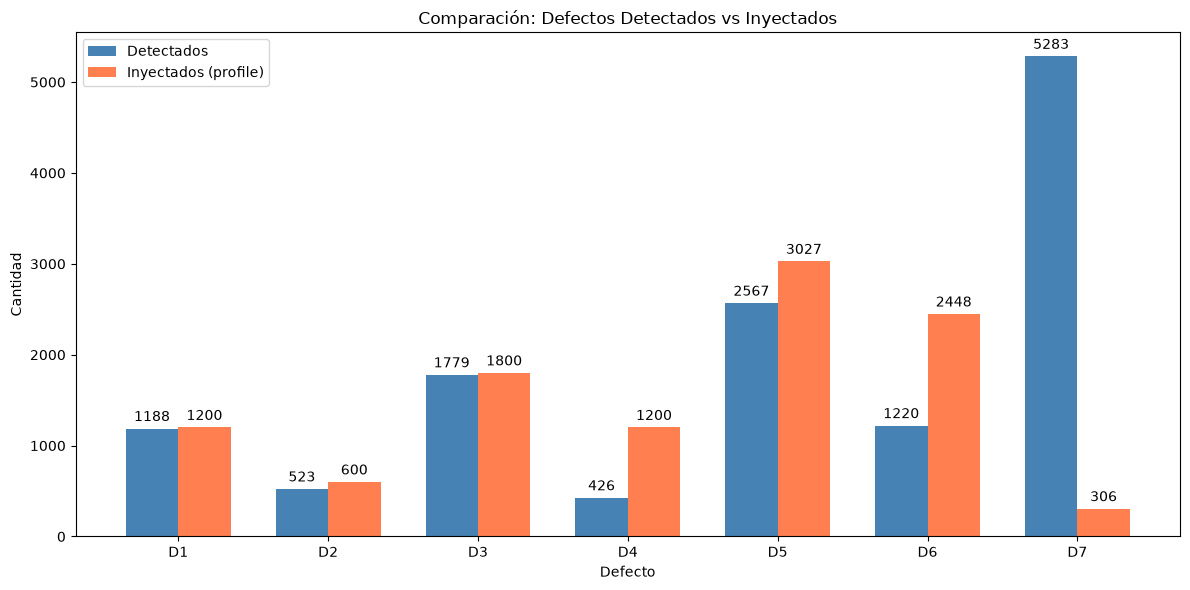


RESUMEN FINAL
Total citas analizadas: 60,581
Total defectos detectados: 12,986
Total defectos inyectados: 10,581
Diferencia total: 2,405


In [12]:
"""
Crear tabla de defectos
"""

defectos = {
    'D1': {'descripcion': 'FK huérfana', 'probabilidad': 0.02},
    'D2': {'descripcion': 'Monto inválido', 'probabilidad': 0.01},
    'D3': {'descripcion': 'Nulo relevante', 'probabilidad': 0.03},
    'D4': {'descripcion': 'Duplicados', 'probabilidad': 0.02},
    'D5': {'descripcion': 'Nomenclatura', 'probabilidad': 0.05},
    'D6': {'descripcion': 'Defecto silencioso', 'probabilidad': 0.04},
    'D7': {'descripcion': 'Regla imposible', 'probabilidad': 0.005}
}

# Contar defectos detectados
detectados = {
    'D1': 0,
    'D2': 0,
    'D3': 0,
    'D4': 0,
    'D5': 0,
    'D6': 0,
    'D7': 0
}

# D1: FK huérfana
valid_patients = set(patients['patient_id'])
detectados['D1'] = len([pid for pid in appointments['patient_id'] if pid not in valid_patients])

# D2: Monto inválido
detectados['D2'] = len(appointments[(appointments['amount_charged'] < 0) | 
                                    (appointments['amount_charged'] == 999999.0)])

# D3: Nulo relevante
detectados['D3'] = len(appointments[appointments['specialty'].isnull() | 
                                    appointments['amount_charged'].isnull()])

# D4: Duplicados (usando el conteo anterior)
detectados['D4'] = total_duplicados

# D5: Nomenclatura (aliases)
detectados['D5'] = len(appointments[appointments['specialty'].isin(aliases)])

# D6: Defecto silencioso (clinic_code con formato alterado)
detectados['D6'] = len(appointments[appointments['clinic_code'].isin(clinic_invalid)])

# D7: Regla imposible
detectados['D7'] = total_imposibles

# Crear DataFrame
df_defectos = pd.DataFrame({
    'Defecto': list(defectos.keys()),
    'Descripción': [v['descripcion'] for v in defectos.values()],
    'Probabilidad': [f"{v['probabilidad']*100:.1f}%" for v in defectos.values()],
    'Detectados': [detectados[k] for k in defectos.keys()],
    'Inyectados (profile)': [profile['defect_counts'][k] for k in defectos.keys()]
})

# Calcular diferencias
df_defectos['Diferencia'] = df_defectos['Detectados'] - df_defectos['Inyectados (profile)']

# Mostrar tabla
display(df_defectos)

# Gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_defectos))
width = 0.35

bars1 = ax.bar(x - width/2, df_defectos['Detectados'], width, label='Detectados', color='steelblue')
bars2 = ax.bar(x + width/2, df_defectos['Inyectados (profile)'], width, label='Inyectados (profile)', color='coral')

ax.set_xlabel('Defecto')
ax.set_ylabel('Cantidad')
ax.set_title('Comparación: Defectos Detectados vs Inyectados')
ax.set_xticks(x)
ax.set_xticklabels(df_defectos['Defecto'])
ax.legend()

# Agregar valores en las barras
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Resumen final
print("\n" + "="*50)
print("RESUMEN FINAL")
print("="*50)
print(f"Total citas analizadas: {len(appointments):,}")
print(f"Total defectos detectados: {sum(detectados.values()):,}")
print(f"Total defectos inyectados: {sum(profile['defect_counts'].values()):,}")
print(f"Diferencia total: {sum(detectados.values()) - sum(profile['defect_counts'].values()):,}")